# teste package gbm

In [3]:
library(ggplot2)
library(lattice)
library(caret)

In [1]:
install.packages("gbm")
library(gbm)


Les packages binaires téléchargés sont dans
	/var/folders/yg/ht7nqbgj78xgjh2pdskv5vx80000gn/T//Rtmptc239s/downloaded_packages


Loaded gbm 2.1.8.1



In [2]:
install.packages("MASS")
library(MASS)


Les packages binaires téléchargés sont dans
	/var/folders/yg/ht7nqbgj78xgjh2pdskv5vx80000gn/T//Rtmptc239s/downloaded_packages


In [4]:
train=sample(1:506,size=374)

In [6]:
Boston[1:2,]

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.00632,18,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.9,4.98,24.0
2,0.02731,0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.9,9.14,21.6


gbm(formula = medv ~ ., distribution = "gaussian", data = Boston[train, 
    ], n.trees = 10000, interaction.depth = 4, shrinkage = 0.01)
A gradient boosted model with gaussian loss function.
10000 iterations were performed.
There were 13 predictors of which 13 had non-zero influence.

,var,rel.inf
,<chr>,<dbl>
rm,rm,40.0974101
lstat,lstat,29.3894123
dis,dis,7.3660192
crim,crim,4.9307177
age,age,3.9761685
nox,nox,3.7275664
ptratio,ptratio,3.7210290
black,black,2.8073079
tax,tax,1.9731207


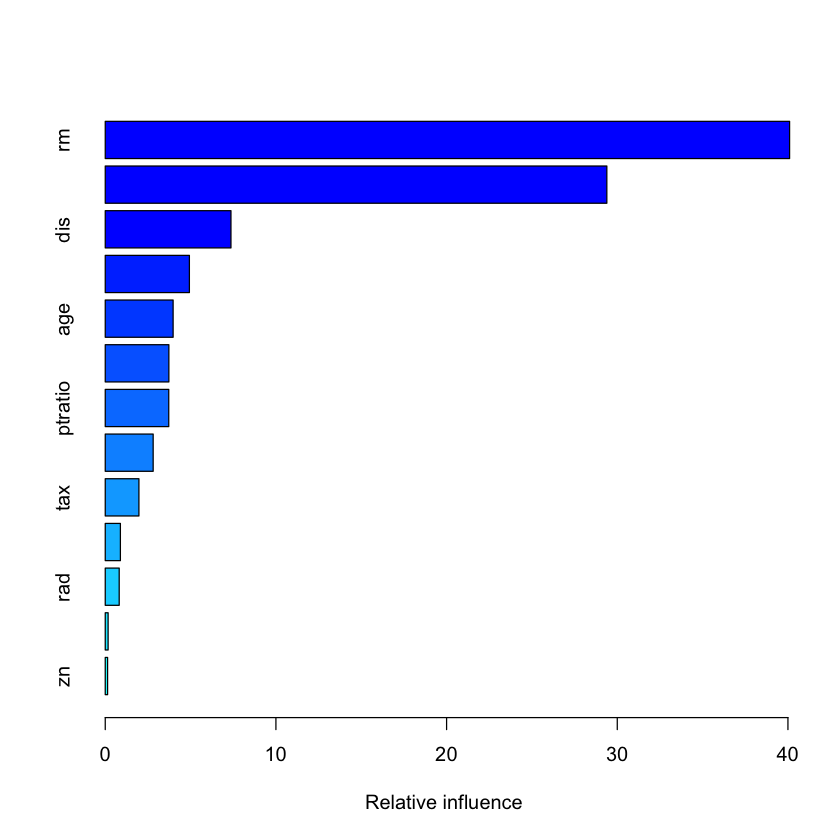

In [12]:
Boston.boost=gbm(medv ~ . ,data = Boston[train,],distribution = "gaussian",n.trees = 10000,shrinkage = 0.01, interaction.depth = 4)
Boston.boost
summary(Boston.boost) #Summary gives a table of Variable Importance and a plot of Variable Importance

gbm(formula = medv ~ ., distribution = "gaussian", data = Boston[-train, 
    ], n.trees = 10000, interaction.depth = 4, shrinkage = 0.01)
A gradient boosted model with gaussian loss function.
10000 iterations were performed.
There were 13 predictors of which 13 had non-zero influence.

,var,rel.inf
,<chr>,<dbl>
rm,rm,39.0194097
lstat,lstat,30.5011608
dis,dis,7.8238509
crim,crim,5.0627313
ptratio,ptratio,3.8420747
age,age,3.7201727
nox,nox,3.2143779
black,black,2.8149232
tax,tax,1.9976356


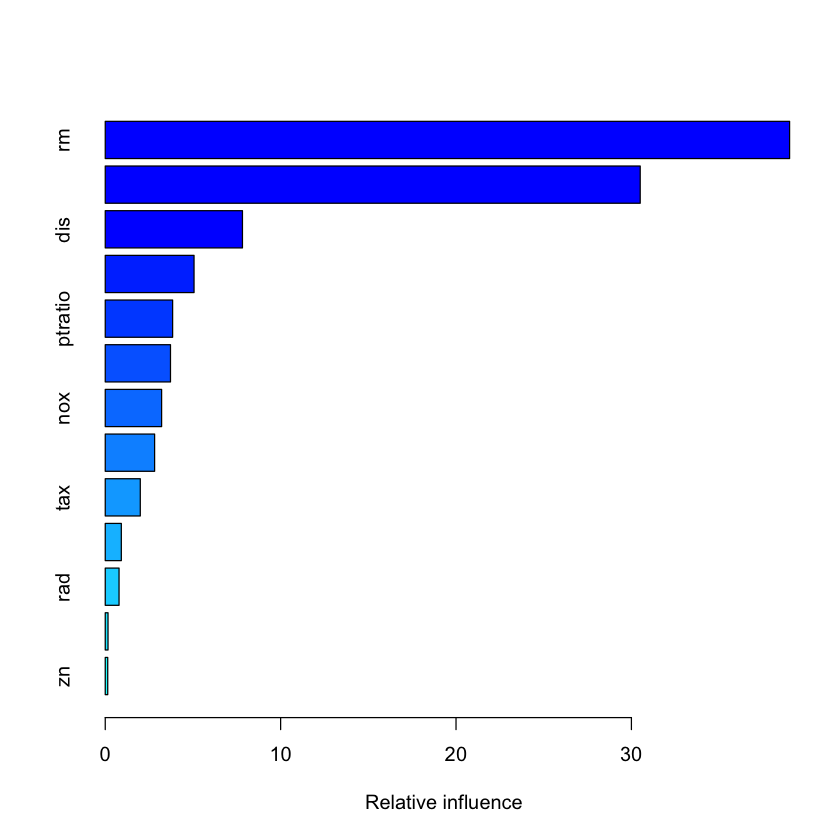

In [16]:
gbm(formula = medv ~ ., distribution = "gaussian", data = Boston[-train,], n.trees = 10000, interaction.depth = 4, shrinkage = 0.01)
summary(Boston.boost)

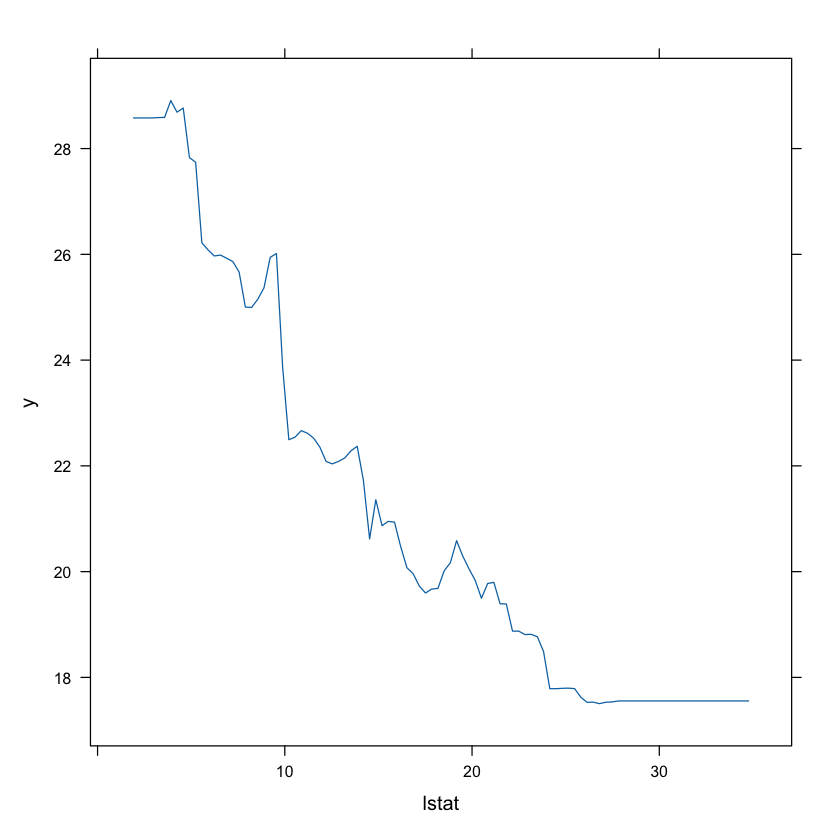

In [17]:
#Plot of Response variable with lstat variable
plot(Boston.boost,i="lstat") 
#Inverse relation with lstat variable

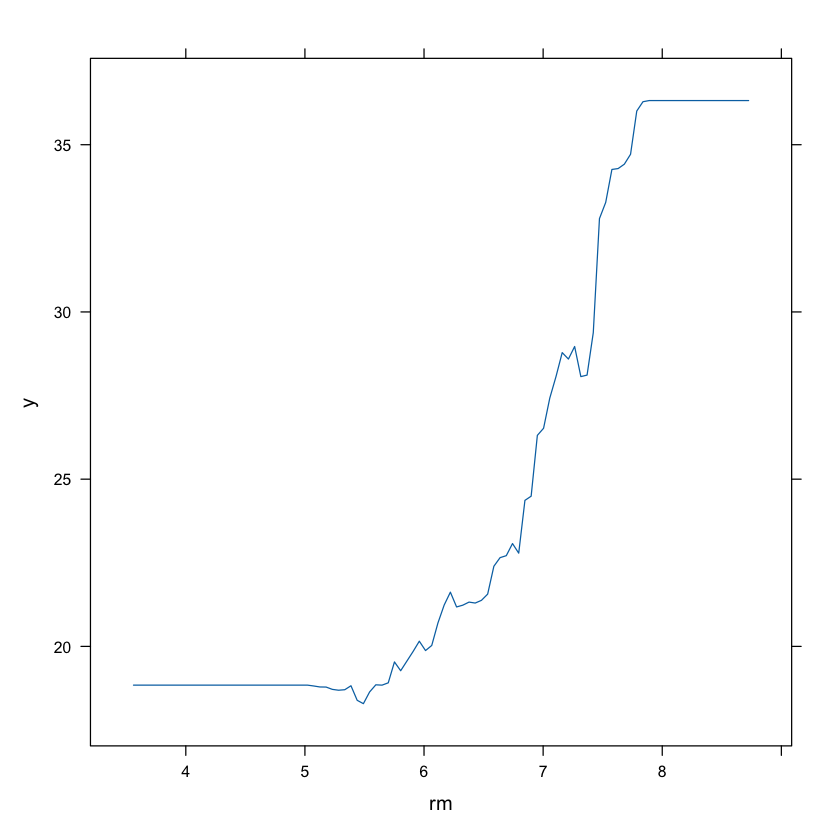

In [18]:
plot(Boston.boost,i="rm") 
#as the average number of rooms increases the the price increases

In [19]:
cor(Boston$lstat,Boston$medv)#negetive correlation coeff-r

[1] -0.7376627

In [20]:
cor(Boston$rm,Boston$medv)#positive correlation coeff-r

[1] 0.6953599

In [25]:
n.trees = seq(from=100 ,to=10000, by=100) #no of trees-a vector of 100 values 

In [26]:
#Generating a Prediction matrix for each Tree
predmatrix<-predict(Boston.boost,Boston[-train,],n.trees = n.trees)
dim(predmatrix) #dimentions of the Prediction Matrix

[1] 132 100

In [32]:
#Calculating The Mean squared Test Error
test.error<-with(Boston[-train,],apply( (predmatrix-medv)^2,2,mean))
head(test.error) #contains the Mean squared test error for each of the 100 trees averaged

100      200      300      400      500      600 
39.38767 25.58591 21.73438 19.77758 18.84586 18.03516

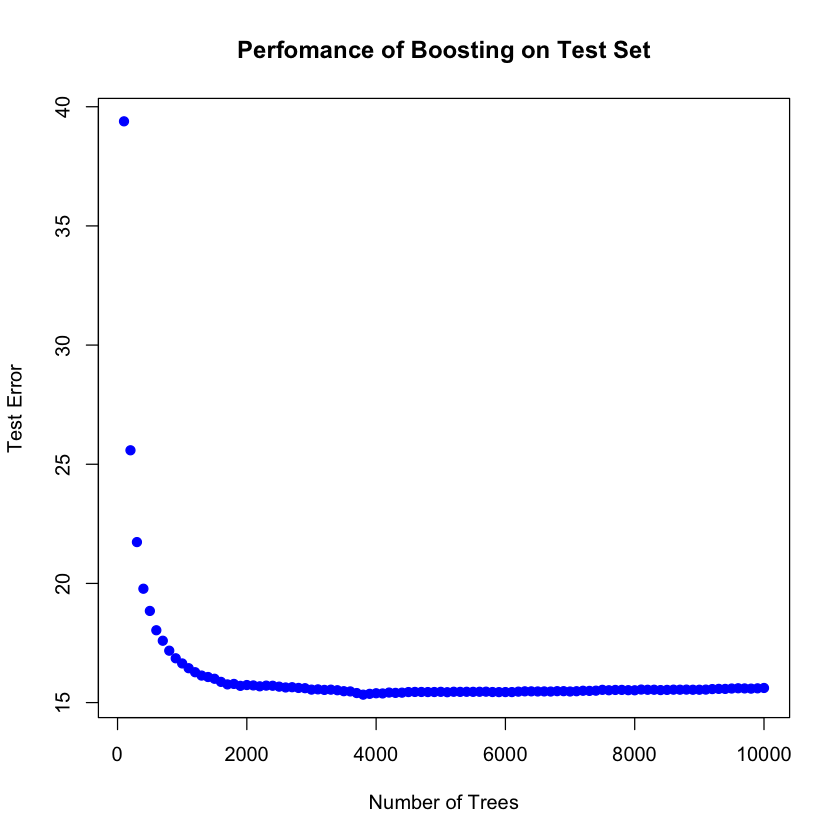

In [28]:
#Plotting the test error vs number of trees

plot(n.trees , test.error , pch=19,col="blue",xlab="Number of Trees",ylab="Test Error", main = "Perfomance of Boosting on Test Set")

# classification avec gbm

In [41]:
data <- iris

In [51]:
summary(data)

  Sepal.Length    Sepal.Width     Petal.Length    Petal.Width   
 Min.   :4.300   Min.   :2.000   Min.   :1.000   Min.   :0.100  
 1st Qu.:5.100   1st Qu.:2.800   1st Qu.:1.600   1st Qu.:0.300  
 Median :5.800   Median :3.000   Median :4.350   Median :1.300  
 Mean   :5.843   Mean   :3.057   Mean   :3.758   Mean   :1.199  
 3rd Qu.:6.400   3rd Qu.:3.300   3rd Qu.:5.100   3rd Qu.:1.800  
 Max.   :7.900   Max.   :4.400   Max.   :6.900   Max.   :2.500  
       Species  
 setosa    :50  
 versicolor:50  
 virginica :50  
                
                
                

In [46]:
# createDataPartition() function from the caret package to split the original dataset into a training and testing set and split data into training (80%) and testing set (20%)
parts = createDataPartition(data$Species, p = 0.7, list = F)
train = data[parts, ]
test = data[-parts, ]

In [52]:
# train a model using our training data
model_gbm = gbm(Species ~.,
              data = train,
              cv.folds = 10,
              shrinkage = .01,
              n.minobsinnode = 10,
              n.trees = 500)       # 500 tress to be built

#summary(model_gbm)

Distribution not specified, assuming multinomial ...


Warning message:
“Setting `distribution = "multinomial"` is ill-advised as it is currently broken. It exists only for backwards compatibility. Use at your own risk.”


In [53]:
?expand.grid

In [48]:
gbmGrid <-  expand.grid(interaction.depth = c(1, 5, 9), 
                        n.trees = (1:30)*50, 
                        shrinkage = 0.1,
                        n.minobsinnode = 20)
                        
nrow(gbmGrid)

set.seed(825)
gbmFit2 <- train(Class ~ ., data = training, 
                 method = "gbm", 
                 trControl = fitControl, 
                 verbose = FALSE, 
                 ## Now specify the exact models 
                 ## to evaluate:
                 tuneGrid = gbmGrid)
gbmFit2

In [54]:
require(utils)

In [55]:
expand.grid(height = seq(60, 80, 5), weight = seq(100, 300, 50),
            sex = c("Male","Female"))

x <- seq(0, 10, length.out = 100)
y <- seq(-1, 1, length.out = 20)
d1 <- expand.grid(x = x, y = y)
d2 <- expand.grid(x = x, y = y, KEEP.OUT.ATTRS = FALSE)
object.size(d1) - object.size(d2)

height,weight,sex
<dbl>,<dbl>,<fct>
60,100,Male
65,100,Male
70,100,Male
75,100,Male
80,100,Male
60,150,Male
65,150,Male
70,150,Male
75,150,Male


9904 bytes

# 5.3 Basic Parameter Tuning caret docu

In [56]:
fitControl <- trainControl(## 10-fold CV
                           method = "repeatedcv",
                           number = 10,
                           ## repeated ten times
                           repeats = 10)

In [60]:
set.seed(825)
gbmFit1 <- train(Species ~ ., data = data, 
                 method = "gbm", 
                 trControl = fitControl,
                 ## This last option is actually one
                 ## for gbm() that passes through
                 verbose = FALSE)
gbmFit1

Stochastic Gradient Boosting 

150 samples
  4 predictor
  3 classes: 'setosa', 'versicolor', 'virginica' 

No pre-processing
Resampling: Cross-Validated (10 fold, repeated 10 times) 
Summary of sample sizes: 135, 135, 135, 135, 135, 135, ... 
Resampling results across tuning parameters:

  interaction.depth  n.trees  Accuracy   Kappa
  1                   50      0.9466667  0.920
  1                  100      0.9406667  0.911
  1                  150      0.9386667  0.908
  2                   50      0.9433333  0.915
  2                  100      0.9413333  0.912
  2                  150      0.9413333  0.912
  3                   50      0.9426667  0.914
  3                  100      0.9393333  0.909
  3                  150      0.9366667  0.905

Tuning parameter 'shrinkage' was held constant at a value of 0.1

Tuning parameter 'n.minobsinnode' was held constant at a value of 10
Accuracy was used to select the optimal model using the largest value.
The final values used for the mod

In [61]:
gbmGrid <-  expand.grid(interaction.depth = c(1, 5, 9), 
                        n.trees = (1:30)*50, 
                        shrinkage = 0.1,
                        n.minobsinnode = 20)
                        
nrow(gbmGrid)

set.seed(825)
gbmFit2 <- train(Species ~ ., data = data, 
                 method = "gbm", 
                 trControl = fitControl, 
                 verbose = FALSE, 
                 ## Now specify the exact models 
                 ## to evaluate:
                 tuneGrid = gbmGrid)
gbmFit2

[1] 90

Stochastic Gradient Boosting 

150 samples
  4 predictor
  3 classes: 'setosa', 'versicolor', 'virginica' 

No pre-processing
Resampling: Cross-Validated (10 fold, repeated 10 times) 
Summary of sample sizes: 135, 135, 135, 135, 135, 135, ... 
Resampling results across tuning parameters:

  interaction.depth  n.trees  Accuracy   Kappa
  1                    50     0.9493333  0.924
  1                   100     0.9460000  0.919
  1                   150     0.9440000  0.916
  1                   200     0.9433333  0.915
  1                   250     0.9413333  0.912
  1                   300     0.9406667  0.911
  1                   350     0.9413333  0.912
  1                   400     0.9393333  0.909
  1                   450     0.9373333  0.906
  1                   500     0.9373333  0.906
  1                   550     0.9366667  0.905
  1                   600     0.9373333  0.906
  1                   650     0.9340000  0.901
  1                   700     0.9346667  0.902
  1  

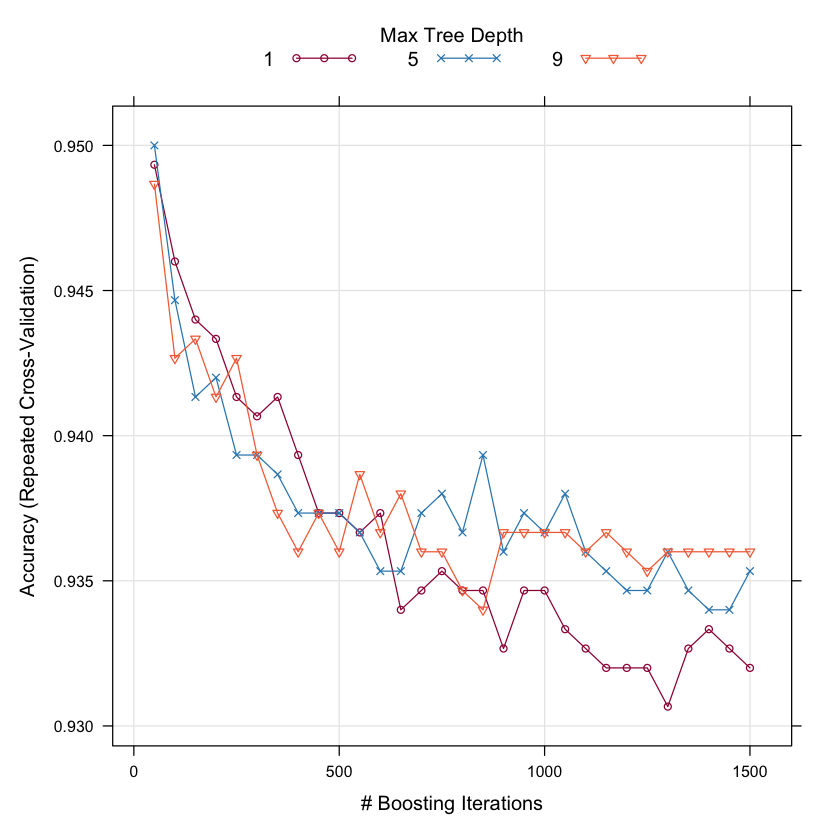

In [62]:
trellis.par.set(caretTheme())
plot(gbmFit2)  

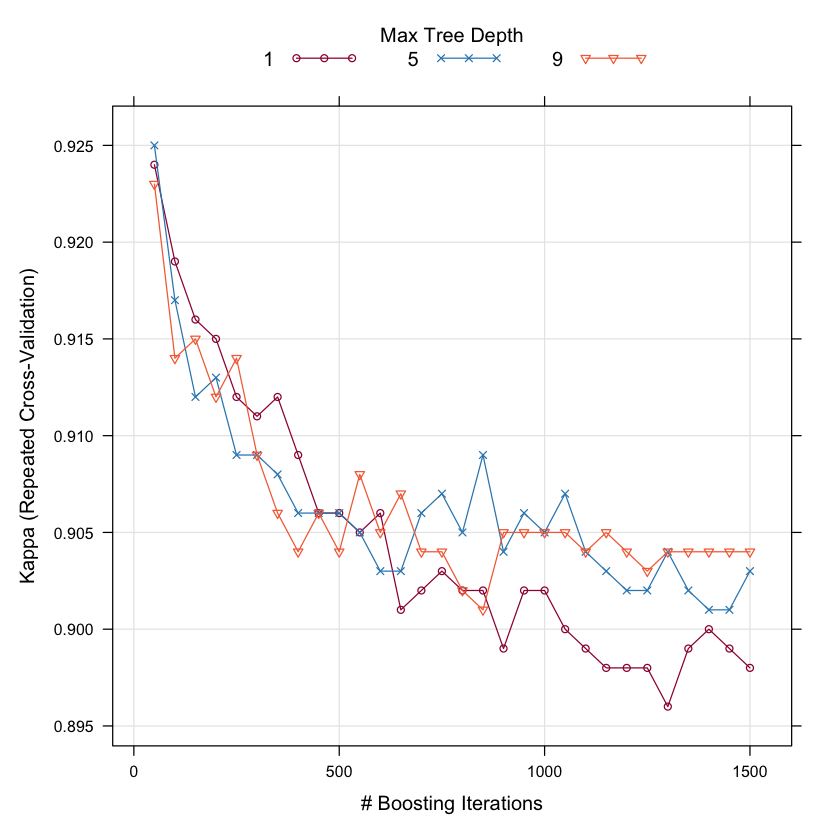

In [63]:
trellis.par.set(caretTheme())
plot(gbmFit2, metric = "Kappa")

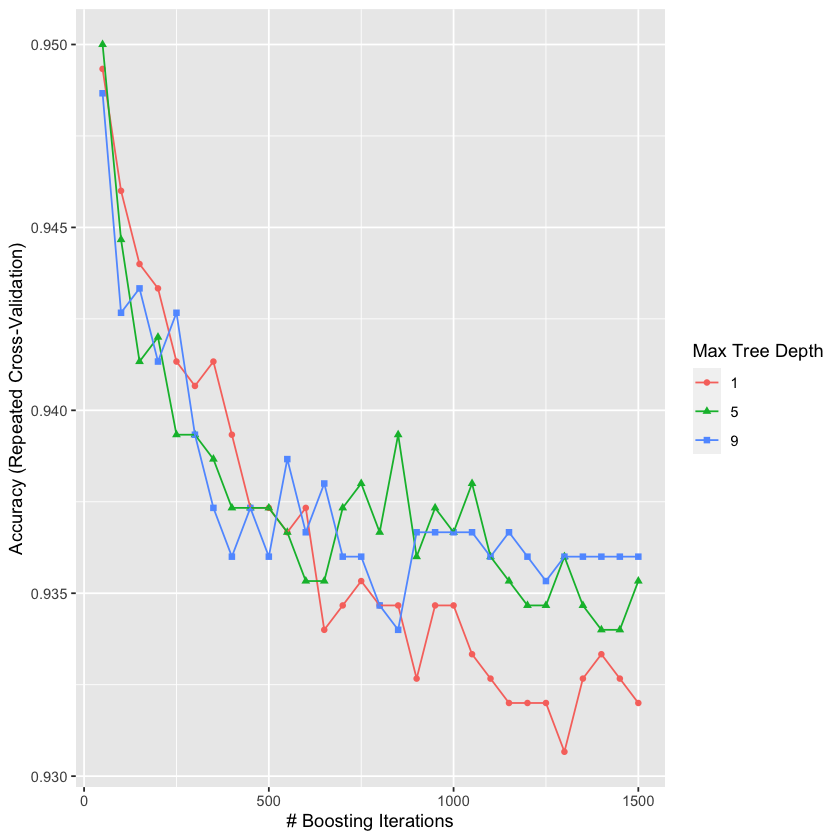

In [64]:
ggplot(gbmFit2)  

In [ ]:
predict(gbmFit2, newdata = head(testing))

# teste sur notre dataset

In [4]:
train_values <- read.csv("train_values.csv",stringsAsFactors = T)
test_values <- read.csv("test_values.csv",stringsAsFactors = T)
train_labels <- read.csv("train_labels.csv",stringsAsFactors = T)
submission_format <- read.csv("submission_format.csv",stringsAsFactors = T)

In [24]:
data <- merge(train_values,train_labels,by=c('building_id','building_id'),all.x=T)
data <- data[,-1]
data[39] <- lapply(data[39], function(x) as.factor(x))
nzv <- nearZeroVar(data)
data <- data[, -nzv]

In [25]:
data <- data[sample(1:nrow(data)),]
test <- data[40001:41001,]
data <- data[1:40000,]

In [232]:
data[1:2,]

,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,⋯,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,count_families,has_secondary_use,has_secondary_use_agriculture,damage_grade
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>,<fct>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>
112858,15,644,11587,2,25,4,4,t,r,n,⋯,1,1,0,0,1,1,1,0,0,3
234649,27,1394,3168,3,25,5,6,t,r,q,⋯,0,1,0,0,0,0,1,0,0,3


In [8]:
fitControl <- trainControl(## 10-fold CV
                           method = "repeatedcv",
                           number = 5) #repeats = 10 a ajouter 

In [231]:
set.seed(825)
gbmFit1 <- train(damage_grade ~ ., data = data, 
                 method = "gbm", 
                 trControl = fitControl,
                 ## This last option is actually one
                 ## for gbm() that passes through
                 verbose = FALSE)
gbmFit1

Warning message in (function (x, y, offset = NULL, misc = NULL, distribution = "bernoulli", :
“variable 16: ground_floor_typem has no variation.”
Warning message in (function (x, y, offset = NULL, misc = NULL, distribution = "bernoulli", :
“variable 16: ground_floor_typem has no variation.”
Warning message in (function (x, y, offset = NULL, misc = NULL, distribution = "bernoulli", :
“variable 16: ground_floor_typem has no variation.”


Stochastic Gradient Boosting 

1000 samples
  22 predictor
   3 classes: '1', '2', '3' 

No pre-processing
Resampling: Cross-Validated (10 fold, repeated 1 times) 
Summary of sample sizes: 899, 901, 899, 900, 900, 900, ... 
Resampling results across tuning parameters:

  interaction.depth  n.trees  Accuracy   Kappa    
  1                   50      0.6079248  0.2298382
  1                  100      0.6219058  0.2710335
  1                  150      0.6249258  0.2857309
  2                   50      0.6148852  0.2588508
  2                  100      0.6208656  0.2849946
  2                  150      0.6108749  0.2705364
  3                   50      0.6189155  0.2710401
  3                  100      0.6179753  0.2844658
  3                  150      0.6309759  0.3141959

Tuning parameter 'shrinkage' was held constant at a value of 0.1

Tuning parameter 'n.minobsinnode' was held constant at a value of 10
Accuracy was used to select the optimal model using the largest value.
The final val

In [200]:
pred_test <- predict(gbmFit1, newdata = test[,1:22])

In [213]:

cfm <- matrix(0, nrow = 3, ncol = 3)
for (j in 1:nrow(test)){
    cfm[pred_test[j],test[j,23]] <- cfm[pred_test[j],test[j,23]]+1
}
TP <- c(cfm[1,1],cfm[2,2],cfm[3,3])
FP <- c(cfm[2,1]+cfm[3,1],cfm[1,2]+cfm[3,2],cfm[1,3]+cfm[2,3])
FN <- c(cfm[1,2]+cfm[1,3],cfm[2,1]+cfm[2,3],cfm[3,1]+cfm[3,2])
P_micro <- sum(TP)/sum(TP+FP)
R_micro <- sum(TP)/sum(TP+FN)
print((2*P_micro*R_micro)/(P_micro+R_micro))

[1] 0.6773227


- number of iterations, i.e. trees, (called n.trees in the gbm function)
- complexity of the tree, called interaction.depth
- learning rate: how quickly the algorithm adapts, called shrinkage
- the minimum number of training set samples in a node to commence splitting (n.minobsinnode)

In [9]:
fitControl <- trainControl(## 10-fold CV
                           method = "repeatedcv",
                           number = 5) #repeats = 10 a ajouter 

In [12]:
gbmGrid <-  expand.grid(interaction.depth = c(5), 
                        n.trees = (1:9)*100, 
                        shrinkage = 0.1,
                        n.minobsinnode = 20)

set.seed(825)
gbmFit2 <- train(damage_grade ~ ., data = data, 
                 method = "gbm", 
                 trControl = fitControl, 
                 verbose = FALSE, 
                 ## Now specify the exact models 
                 ## to evaluate:
                 tuneGrid = gbmGrid)
gbmFit2

Stochastic Gradient Boosting 

10000 samples
   22 predictor
    3 classes: '1', '2', '3' 

No pre-processing
Resampling: Cross-Validated (5 fold, repeated 1 times) 
Summary of sample sizes: 8000, 8001, 7999, 8000, 8000 
Resampling results across tuning parameters:

  n.trees  Accuracy   Kappa    
  100      0.6660000  0.3507467
  200      0.6700998  0.3652987
  300      0.6696991  0.3674201
  400      0.6675000  0.3655780
  500      0.6616999  0.3561586
  600      0.6652002  0.3646272
  700      0.6620010  0.3594318
  800      0.6621004  0.3616269
  900      0.6631011  0.3642757

Tuning parameter 'interaction.depth' was held constant at a value of 5

Tuning parameter 'shrinkage' was held constant at a value of 0.1

Tuning parameter 'n.minobsinnode' was held constant at a value of 20
Accuracy was used to select the optimal model using the largest value.
The final values used for the model were n.trees = 200, interaction.depth =
 5, shrinkage = 0.1 and n.minobsinnode = 20.

In [18]:
gbmGrid <-  expand.grid(interaction.depth = c(5), 
                        n.trees = (5:10)*50, 
                        shrinkage = 0.1,
                        n.minobsinnode = 20)

set.seed(825)
gbmFit2 <- train(damage_grade ~ ., data = data, 
                 method = "gbm", 
                 trControl = fitControl, 
                 verbose = FALSE, 
                 ## Now specify the exact models 
                 ## to evaluate:
                 tuneGrid = gbmGrid)
gbmFit2

Stochastic Gradient Boosting 

20000 samples
   22 predictor
    3 classes: '1', '2', '3' 

No pre-processing
Resampling: Cross-Validated (5 fold, repeated 1 times) 
Summary of sample sizes: 15999, 16001, 16000, 16001, 15999 
Resampling results across tuning parameters:

  n.trees  Accuracy   Kappa    
  250      0.6912991  0.4021817
  300      0.6939992  0.4081238
  350      0.6944492  0.4106140
  400      0.6934987  0.4101994
  450      0.6955496  0.4137684
  500      0.6958492  0.4154206

Tuning parameter 'interaction.depth' was held constant at a value of 5

Tuning parameter 'shrinkage' was held constant at a value of 0.1

Tuning parameter 'n.minobsinnode' was held constant at a value of 20
Accuracy was used to select the optimal model using the largest value.
The final values used for the model were n.trees = 500, interaction.depth =
 5, shrinkage = 0.1 and n.minobsinnode = 20.

In [19]:
gbmGrid <-  expand.grid(interaction.depth = c(5), 
                        n.trees = (10:15)*50, 
                        shrinkage = 0.1,
                        n.minobsinnode = 20)

set.seed(825)
gbmFit2 <- train(damage_grade ~ ., data = data, 
                 method = "gbm", 
                 trControl = fitControl, 
                 verbose = FALSE, 
                 ## Now specify the exact models 
                 ## to evaluate:
                 tuneGrid = gbmGrid)
gbmFit2

Stochastic Gradient Boosting 

20000 samples
   22 predictor
    3 classes: '1', '2', '3' 

No pre-processing
Resampling: Cross-Validated (5 fold, repeated 1 times) 
Summary of sample sizes: 15999, 16001, 16000, 16001, 15999 
Resampling results across tuning parameters:

  n.trees  Accuracy   Kappa    
  500      0.6958492  0.4154206
  550      0.6965494  0.4185200
  600      0.6977993  0.4208624
  650      0.6970494  0.4203817
  700      0.6957000  0.4180386
  750      0.6949499  0.4178508

Tuning parameter 'interaction.depth' was held constant at a value of 5

Tuning parameter 'shrinkage' was held constant at a value of 0.1

Tuning parameter 'n.minobsinnode' was held constant at a value of 20
Accuracy was used to select the optimal model using the largest value.
The final values used for the model were n.trees = 600, interaction.depth =
 5, shrinkage = 0.1 and n.minobsinnode = 20.

In [22]:
gbmGrid <-  expand.grid(interaction.depth = c(5), 
                        n.trees = (1:3)*50+500, 
                        shrinkage = 0.1,
                        n.minobsinnode = 20)

set.seed(825)
gbmFit2 <- train(damage_grade ~ ., data = data, 
                 method = "gbm", 
                 trControl = fitControl, 
                 verbose = FALSE, 
                 ## Now specify the exact models 
                 ## to evaluate:
                 tuneGrid = gbmGrid)
gbmFit2

Stochastic Gradient Boosting 

30000 samples
   22 predictor
    3 classes: '1', '2', '3' 

No pre-processing
Resampling: Cross-Validated (5 fold, repeated 1 times) 
Summary of sample sizes: 24000, 24001, 23999, 24001, 23999 
Resampling results across tuning parameters:

  n.trees  Accuracy   Kappa    
  550      0.6984665  0.4265117
  600      0.6997665  0.4295573
  650      0.7012999  0.4328635

Tuning parameter 'interaction.depth' was held constant at a value of 5

Tuning parameter 'shrinkage' was held constant at a value of 0.1

Tuning parameter 'n.minobsinnode' was held constant at a value of 20
Accuracy was used to select the optimal model using the largest value.
The final values used for the model were n.trees = 650, interaction.depth =
 5, shrinkage = 0.1 and n.minobsinnode = 20.

In [23]:
gbmGrid <-  expand.grid(interaction.depth = c(5), 
                        n.trees = (4:6)*50+500, 
                        shrinkage = 0.1,
                        n.minobsinnode = 20)

set.seed(825)
gbmFit2 <- train(damage_grade ~ ., data = data, 
                 method = "gbm", 
                 trControl = fitControl, 
                 verbose = FALSE, 
                 ## Now specify the exact models 
                 ## to evaluate:
                 tuneGrid = gbmGrid)
gbmFit2

Stochastic Gradient Boosting 

30000 samples
   22 predictor
    3 classes: '1', '2', '3' 

No pre-processing
Resampling: Cross-Validated (5 fold, repeated 1 times) 
Summary of sample sizes: 24000, 24001, 23999, 24001, 23999 
Resampling results across tuning parameters:

  n.trees  Accuracy   Kappa    
  700      0.7016667  0.4340065
  750      0.7018332  0.4342568
  800      0.7008331  0.4330898

Tuning parameter 'interaction.depth' was held constant at a value of 5

Tuning parameter 'shrinkage' was held constant at a value of 0.1

Tuning parameter 'n.minobsinnode' was held constant at a value of 20
Accuracy was used to select the optimal model using the largest value.
The final values used for the model were n.trees = 750, interaction.depth =
 5, shrinkage = 0.1 and n.minobsinnode = 20.

In [26]:
gbmGrid <-  expand.grid(interaction.depth = c(5), 
                        n.trees = (4:6)*50+500, 
                        shrinkage = 0.1,
                        n.minobsinnode = 20)

set.seed(825)
gbmFit2 <- train(damage_grade ~ ., data = data, 
                 method = "gbm", 
                 trControl = fitControl, 
                 verbose = FALSE, 
                 ## Now specify the exact models 
                 ## to evaluate:
                 tuneGrid = gbmGrid)
gbmFit2

Stochastic Gradient Boosting 

40000 samples
   22 predictor
    3 classes: '1', '2', '3' 

No pre-processing
Resampling: Cross-Validated (5 fold, repeated 1 times) 
Summary of sample sizes: 31999, 32000, 32000, 32001, 32000 
Resampling results across tuning parameters:

  n.trees  Accuracy   Kappa    
  700      0.7083748  0.4439284
  750      0.7092749  0.4460867
  800      0.7099749  0.4475622

Tuning parameter 'interaction.depth' was held constant at a value of 5

Tuning parameter 'shrinkage' was held constant at a value of 0.1

Tuning parameter 'n.minobsinnode' was held constant at a value of 20
Accuracy was used to select the optimal model using the largest value.
The final values used for the model were n.trees = 800, interaction.depth =
 5, shrinkage = 0.1 and n.minobsinnode = 20.

In [27]:
gbmGrid <-  expand.grid(interaction.depth = c(5), 
                        n.trees = (6:8)*50+500, 
                        shrinkage = 0.1,
                        n.minobsinnode = 20)

set.seed(825)
gbmFit2 <- train(damage_grade ~ ., data = data, 
                 method = "gbm", 
                 trControl = fitControl, 
                 verbose = FALSE, 
                 ## Now specify the exact models 
                 ## to evaluate:
                 tuneGrid = gbmGrid)
gbmFit2

Stochastic Gradient Boosting 

40000 samples
   22 predictor
    3 classes: '1', '2', '3' 

No pre-processing
Resampling: Cross-Validated (5 fold, repeated 1 times) 
Summary of sample sizes: 31999, 32000, 32000, 32001, 32000 
Resampling results across tuning parameters:

  n.trees  Accuracy   Kappa    
  800      0.7099749  0.4475622
  850      0.7101248  0.4483503
  900      0.7101748  0.4487454

Tuning parameter 'interaction.depth' was held constant at a value of 5

Tuning parameter 'shrinkage' was held constant at a value of 0.1

Tuning parameter 'n.minobsinnode' was held constant at a value of 20
Accuracy was used to select the optimal model using the largest value.
The final values used for the model were n.trees = 900, interaction.depth =
 5, shrinkage = 0.1 and n.minobsinnode = 20.

In [28]:
gbmGrid <-  expand.grid(interaction.depth = c(5), 
                        n.trees = (9:11)*50+500, 
                        shrinkage = 0.1,
                        n.minobsinnode = 20)

set.seed(825)
gbmFit2 <- train(damage_grade ~ ., data = data, 
                 method = "gbm", 
                 trControl = fitControl, 
                 verbose = FALSE, 
                 ## Now specify the exact models 
                 ## to evaluate:
                 tuneGrid = gbmGrid)
gbmFit2

Stochastic Gradient Boosting 

40000 samples
   22 predictor
    3 classes: '1', '2', '3' 

No pre-processing
Resampling: Cross-Validated (5 fold, repeated 1 times) 
Summary of sample sizes: 31999, 32000, 32000, 32001, 32000 
Resampling results across tuning parameters:

  n.trees  Accuracy   Kappa    
   950     0.7109999  0.4504198
  1000     0.7110498  0.4507963
  1050     0.7111999  0.4510066

Tuning parameter 'interaction.depth' was held constant at a value of 5

Tuning parameter 'shrinkage' was held constant at a value of 0.1

Tuning parameter 'n.minobsinnode' was held constant at a value of 20
Accuracy was used to select the optimal model using the largest value.
The final values used for the model were n.trees = 1050, interaction.depth =
 5, shrinkage = 0.1 and n.minobsinnode = 20.

In [30]:
pred_test <- predict(gbmFit2, newdata = test[,1:22])
cfm <- matrix(0, nrow = 3, ncol = 3)
for (j in 1:nrow(test)){
    cfm[pred_test[j],test[j,23]] <- cfm[pred_test[j],test[j,23]]+1
}
TP <- c(cfm[1,1],cfm[2,2],cfm[3,3])
FP <- c(cfm[2,1]+cfm[3,1],cfm[1,2]+cfm[3,2],cfm[1,3]+cfm[2,3])
FN <- c(cfm[1,2]+cfm[1,3],cfm[2,1]+cfm[2,3],cfm[3,1]+cfm[3,2])
P_micro <- sum(TP)/sum(TP+FP)
R_micro <- sum(TP)/sum(TP+FN)
print((2*P_micro*R_micro)/(P_micro+R_micro))

[1] 0.7482517


In [31]:
gbmGrid <-  expand.grid(interaction.depth = c(5), 
                        n.trees = (1:3)*500, 
                        shrinkage = 0.1,
                        n.minobsinnode = 100)

set.seed(825)
gbmFit2 <- train(damage_grade ~ ., data = data, 
                 method = "gbm", 
                 trControl = fitControl, 
                 verbose = FALSE, 
                 ## Now specify the exact models 
                 ## to evaluate:
                 tuneGrid = gbmGrid)
gbmFit2

Stochastic Gradient Boosting 

40000 samples
   22 predictor
    3 classes: '1', '2', '3' 

No pre-processing
Resampling: Cross-Validated (5 fold, repeated 1 times) 
Summary of sample sizes: 31999, 32000, 32000, 32001, 32000 
Resampling results across tuning parameters:

  n.trees  Accuracy   Kappa    
   500     0.7024248  0.4303504
  1000     0.7064499  0.4416188
  1500     0.7085499  0.4482023

Tuning parameter 'interaction.depth' was held constant at a value of 5

Tuning parameter 'shrinkage' was held constant at a value of 0.1

Tuning parameter 'n.minobsinnode' was held constant at a value of 100
Accuracy was used to select the optimal model using the largest value.
The final values used for the model were n.trees = 1500, interaction.depth =
 5, shrinkage = 0.1 and n.minobsinnode = 100.

# optimal n.minobsinnode

In [44]:
data <- merge(train_values,train_labels,by=c('building_id','building_id'),all.x=T)
data <- data[,-1]
data[39] <- lapply(data[39], function(x) as.factor(x))
nzv <- nearZeroVar(data)
data <- data[, -nzv]

In [33]:
set.seed(825)
data <- data[sample(1:nrow(data)),]
test <- data[10001:12001,]
data <- data[1:10000,]

In [34]:
gbmGrid <-  expand.grid(interaction.depth = c(5), 
                        n.trees = (1:3)*50+150, 
                        shrinkage = 0.1,
                        n.minobsinnode = 10)

set.seed(825)
gbmFit2 <- train(damage_grade ~ ., data = data, 
                 method = "gbm", 
                 trControl = fitControl, 
                 verbose = FALSE, 
                 ## Now specify the exact models 
                 ## to evaluate:
                 tuneGrid = gbmGrid)
gbmFit2

Stochastic Gradient Boosting 

10000 samples
   22 predictor
    3 classes: '1', '2', '3' 

No pre-processing
Resampling: Cross-Validated (5 fold, repeated 1 times) 
Summary of sample sizes: 8000, 8001, 7999, 8000, 8000 
Resampling results across tuning parameters:

  n.trees  Accuracy   Kappa    
  200      0.6753973  0.3729700
  250      0.6754971  0.3740117
  300      0.6754981  0.3770965

Tuning parameter 'interaction.depth' was held constant at a value of 5

Tuning parameter 'shrinkage' was held constant at a value of 0.1

Tuning parameter 'n.minobsinnode' was held constant at a value of 10
Accuracy was used to select the optimal model using the largest value.
The final values used for the model were n.trees = 300, interaction.depth =
 5, shrinkage = 0.1 and n.minobsinnode = 10.

In [38]:
for (i in seq(10,50,10)){
    gbmGrid <-  expand.grid(interaction.depth = c(5), 
                        n.trees = (1:3)*50+150, 
                        shrinkage = 0.1,
                        n.minobsinnode = i)

    set.seed(825)
    gbmFit2 <- train(damage_grade ~ ., data = data, 
                 method = "gbm", 
                 trControl = fitControl, 
                 verbose = FALSE, 
                 ## Now specify the exact models 
                 ## to evaluate:
                 tuneGrid = gbmGrid)
    print(gbmFit2)
    
    pred_test <- predict(gbmFit2, newdata = test[,1:22])
    cfm <- matrix(0, nrow = 3, ncol = 3)
    for (j in 1:nrow(test)){
        cfm[pred_test[j],test[j,23]] <- cfm[pred_test[j],test[j,23]]+1
    }
    TP <- c(cfm[1,1],cfm[2,2],cfm[3,3])
    FP <- c(cfm[2,1]+cfm[3,1],cfm[1,2]+cfm[3,2],cfm[1,3]+cfm[2,3])
    FN <- c(cfm[1,2]+cfm[1,3],cfm[2,1]+cfm[2,3],cfm[3,1]+cfm[3,2])
    P_micro <- sum(TP)/sum(TP+FP)
    R_micro <- sum(TP)/sum(TP+FN)
    print((2*P_micro*R_micro)/(P_micro+R_micro))
}

Stochastic Gradient Boosting 

10000 samples
   22 predictor
    3 classes: '1', '2', '3' 

No pre-processing
Resampling: Cross-Validated (5 fold, repeated 1 times) 
Summary of sample sizes: 8000, 8001, 7999, 8000, 8000 
Resampling results across tuning parameters:

  n.trees  Accuracy   Kappa    
  200      0.6753973  0.3729700
  250      0.6754971  0.3740117
  300      0.6754981  0.3770965

Tuning parameter 'interaction.depth' was held constant at a value of 5

Tuning parameter 'shrinkage' was held constant at a value of 0.1

Tuning parameter 'n.minobsinnode' was held constant at a value of 10
Accuracy was used to select the optimal model using the largest value.
The final values used for the model were n.trees = 300, interaction.depth =
 5, shrinkage = 0.1 and n.minobsinnode = 10.
[1] 0.6561719
Stochastic Gradient Boosting 

10000 samples
   22 predictor
    3 classes: '1', '2', '3' 

No pre-processing
Resampling: Cross-Validated (5 fold, repeated 1 times) 
Summary of sample sizes: 

In [39]:
for (i in seq(30,50,4)){
    gbmGrid <-  expand.grid(interaction.depth = c(5), 
                        n.trees = (1:3)*50+150, 
                        shrinkage = 0.1,
                        n.minobsinnode = i)

    set.seed(825)
    gbmFit2 <- train(damage_grade ~ ., data = data, 
                 method = "gbm", 
                 trControl = fitControl, 
                 verbose = FALSE, 
                 ## Now specify the exact models 
                 ## to evaluate:
                 tuneGrid = gbmGrid)
    print(gbmFit2)
    
    pred_test <- predict(gbmFit2, newdata = test[,1:22])
    cfm <- matrix(0, nrow = 3, ncol = 3)
    for (j in 1:nrow(test)){
        cfm[pred_test[j],test[j,23]] <- cfm[pred_test[j],test[j,23]]+1
    }
    TP <- c(cfm[1,1],cfm[2,2],cfm[3,3])
    FP <- c(cfm[2,1]+cfm[3,1],cfm[1,2]+cfm[3,2],cfm[1,3]+cfm[2,3])
    FN <- c(cfm[1,2]+cfm[1,3],cfm[2,1]+cfm[2,3],cfm[3,1]+cfm[3,2])
    P_micro <- sum(TP)/sum(TP+FP)
    R_micro <- sum(TP)/sum(TP+FN)
    print((2*P_micro*R_micro)/(P_micro+R_micro))
}

Stochastic Gradient Boosting 

10000 samples
   22 predictor
    3 classes: '1', '2', '3' 

No pre-processing
Resampling: Cross-Validated (5 fold, repeated 1 times) 
Summary of sample sizes: 8000, 8001, 7999, 8000, 8000 
Resampling results across tuning parameters:

  n.trees  Accuracy   Kappa    
  200      0.6747995  0.3717618
  250      0.6780994  0.3794597
  300      0.6763989  0.3791111

Tuning parameter 'interaction.depth' was held constant at a value of 5

Tuning parameter 'shrinkage' was held constant at a value of 0.1

Tuning parameter 'n.minobsinnode' was held constant at a value of 30
Accuracy was used to select the optimal model using the largest value.
The final values used for the model were n.trees = 250, interaction.depth =
 5, shrinkage = 0.1 and n.minobsinnode = 30.
[1] 0.6611694
Stochastic Gradient Boosting 

10000 samples
   22 predictor
    3 classes: '1', '2', '3' 

No pre-processing
Resampling: Cross-Validated (5 fold, repeated 1 times) 
Summary of sample sizes: 

In [40]:
for (i in 38:42){
    gbmGrid <-  expand.grid(interaction.depth = c(5), 
                        n.trees = (1:3)*50+150, 
                        shrinkage = 0.1,
                        n.minobsinnode = i)

    set.seed(825)
    gbmFit2 <- train(damage_grade ~ ., data = data, 
                 method = "gbm", 
                 trControl = fitControl, 
                 verbose = FALSE, 
                 ## Now specify the exact models 
                 ## to evaluate:
                 tuneGrid = gbmGrid)
    print(gbmFit2)
    
    pred_test <- predict(gbmFit2, newdata = test[,1:22])
    cfm <- matrix(0, nrow = 3, ncol = 3)
    for (j in 1:nrow(test)){
        cfm[pred_test[j],test[j,23]] <- cfm[pred_test[j],test[j,23]]+1
    }
    TP <- c(cfm[1,1],cfm[2,2],cfm[3,3])
    FP <- c(cfm[2,1]+cfm[3,1],cfm[1,2]+cfm[3,2],cfm[1,3]+cfm[2,3])
    FN <- c(cfm[1,2]+cfm[1,3],cfm[2,1]+cfm[2,3],cfm[3,1]+cfm[3,2])
    P_micro <- sum(TP)/sum(TP+FP)
    R_micro <- sum(TP)/sum(TP+FN)
    print((2*P_micro*R_micro)/(P_micro+R_micro))
}

Stochastic Gradient Boosting 

10000 samples
   22 predictor
    3 classes: '1', '2', '3' 

No pre-processing
Resampling: Cross-Validated (5 fold, repeated 1 times) 
Summary of sample sizes: 8000, 8001, 7999, 8000, 8000 
Resampling results across tuning parameters:

  n.trees  Accuracy   Kappa    
  200      0.6753985  0.3725497
  250      0.6772988  0.3773746
  300      0.6769986  0.3793226

Tuning parameter 'interaction.depth' was held constant at a value of 5

Tuning parameter 'shrinkage' was held constant at a value of 0.1

Tuning parameter 'n.minobsinnode' was held constant at a value of 38
Accuracy was used to select the optimal model using the largest value.
The final values used for the model were n.trees = 250, interaction.depth =
 5, shrinkage = 0.1 and n.minobsinnode = 38.
[1] 0.6651674
Stochastic Gradient Boosting 

10000 samples
   22 predictor
    3 classes: '1', '2', '3' 

No pre-processing
Resampling: Cross-Validated (5 fold, repeated 1 times) 
Summary of sample sizes: 

In [47]:
data <- merge(train_values,train_labels,by=c('building_id','building_id'),all.x=T)
data <- data[,-1]
data[39] <- lapply(data[39], function(x) as.factor(x))
nzv <- nearZeroVar(data)
data <- data[, -nzv]

In [48]:
set.seed(825)
data <- data[sample(1:nrow(data)),]
test <- data[20001:22001,]
data <- data[2:20000,]

In [50]:
dim(data)

[1] 19999    23

In [51]:
for (i in seq(10,50,10)){
    gbmGrid <-  expand.grid(interaction.depth = c(5), 
                        n.trees = (1:3)*50+500, 
                        shrinkage = 0.1,
                        n.minobsinnode = i)

    set.seed(825)
    gbmFit2 <- train(damage_grade ~ ., data = data, 
                 method = "gbm", 
                 trControl = fitControl, 
                 verbose = FALSE, 
                 ## Now specify the exact models 
                 ## to evaluate:
                 tuneGrid = gbmGrid)
    print(gbmFit2)
    
    pred_test <- predict(gbmFit2, newdata = test[,1:22])
    cfm <- matrix(0, nrow = 3, ncol = 3)
    for (j in 1:nrow(test)){
        cfm[pred_test[j],test[j,23]] <- cfm[pred_test[j],test[j,23]]+1
    }
    TP <- c(cfm[1,1],cfm[2,2],cfm[3,3])
    FP <- c(cfm[2,1]+cfm[3,1],cfm[1,2]+cfm[3,2],cfm[1,3]+cfm[2,3])
    FN <- c(cfm[1,2]+cfm[1,3],cfm[2,1]+cfm[2,3],cfm[3,1]+cfm[3,2])
    P_micro <- sum(TP)/sum(TP+FP)
    R_micro <- sum(TP)/sum(TP+FN)
    print((2*P_micro*R_micro)/(P_micro+R_micro))
}

Stochastic Gradient Boosting 

19999 samples
   22 predictor
    3 classes: '1', '2', '3' 

No pre-processing
Resampling: Cross-Validated (5 fold, repeated 1 times) 
Summary of sample sizes: 16000, 15999, 15998, 15999, 16000 
Resampling results across tuning parameters:

  n.trees  Accuracy   Kappa    
  550      0.6975347  0.4236020
  600      0.6962346  0.4215776
  650      0.6971347  0.4238237

Tuning parameter 'interaction.depth' was held constant at a value of 5

Tuning parameter 'shrinkage' was held constant at a value of 0.1

Tuning parameter 'n.minobsinnode' was held constant at a value of 10
Accuracy was used to select the optimal model using the largest value.
The final values used for the model were n.trees = 550, interaction.depth =
 5, shrinkage = 0.1 and n.minobsinnode = 10.
[1] 0.6731634
Stochastic Gradient Boosting 

19999 samples
   22 predictor
    3 classes: '1', '2', '3' 

No pre-processing
Resampling: Cross-Validated (5 fold, repeated 1 times) 
Summary of sample si

!!!!!!!!!

In [ ]:
fitControl <- trainControl(method = "repeatedcv",
                           number = 10,
                           repeats = 10,
                           ## Estimate class probabilities
                           classProbs = TRUE,
                           ## Evaluate performance using 
                           ## the following function
                           summaryFunction = twoClassSummary)

set.seed(825)
gbmFit3 <- train(Class ~ ., data = training, 
                 method = "gbm", 
                 trControl = fitControl, 
                 verbose = FALSE, 
                 tuneGrid = gbmGrid,
                 ## Specify which metric to optimize
                 metric = "ROC")
gbmFit3

In [ ]:
whichTwoPct <- tolerance(gbmFit3$results, metric = "ROC", 
                         tol = 2, maximize = TRUE) 

In [ ]:
gbmFit3$results[whichTwoPct,1:6]

# Training sur le full dataset

In [52]:
data <- merge(train_values,train_labels,by=c('building_id','building_id'),all.x=T)
data <- data[,-1]
data[39] <- lapply(data[39], function(x) as.factor(x))
nzv <- nearZeroVar(data)
data <- data[, -nzv]

In [53]:
dim(data)

[1] 260601     23

In [ ]:
fitControl <- trainControl(method = "repeatedcv",
                           number = 5) 

gbmGrid <-  expand.grid(interaction.depth = c(5), 
                        n.trees = 1200, 
                        shrinkage = 0.1,
                        n.minobsinnode = 20)

set.seed(825)
gbmFit2 <- train(damage_grade ~ ., data = data, 
                 method = "gbm", 
                 trControl = fitControl, 
                 verbose = FALSE, 
                 ## Now specify the exact models 
                 ## to evaluate:
                 tuneGrid = gbmGrid)
gbmFit2